In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matrix_solvers import gaussian_elimination, gauss_seidel, jacobi_iteration

In [3]:
def create_grid(R,I):
    
    '''
    Create cell edges and centers for a domain of
    size R and for I cells
    
    Args:
        R: size of domain
        I: number of cells
        
    Returns:
        Delta_r: width of each cell
        centers: cell centers of the grid
        edges: cell edges of the grid
    '''
    
    Delta_r = float(R)/I # divide size by # of cells
    # calculate the centers by getting each Delta_r
    # and adding 0.5 Delta_R
    centers = np.arange(I)*Delta_r + 0.5*Delta_r
    # Get edges by going beyond one cell
    edges = np.arange(I+1)*Delta_r
    
    return Delta_r, centers, edges

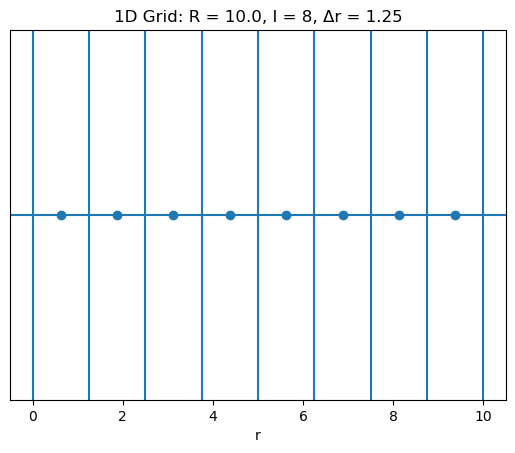

In [4]:
# Example usage
R = 10.0
I = 8

Delta_r, centers, edges = create_grid(R, I)

plt.figure()

# Plot cell edges as vertical lines
for e in edges:
    plt.axvline(e)

# Plot centers as points
plt.plot(centers, np.zeros_like(centers), 'o')

# Reference horizontal line
plt.axhline(0)

plt.xlabel("r")
plt.title(f"1D Grid: R = {R}, I = {I}, Δr = {Delta_r}")
plt.yticks([])

plt.show()

In [5]:
def diffusion_solver(R, I,
                     D, Sig_a, nuSig_f, Q,
                     BC, geometry, method=0):
    
    '''
    Solve the diffusion equation in a 1-D geometry
    use cell-averaged quantities
    
    Args:
        R: size of domain
        I: number of cells
        D: function, D(r), returns diffusion coefficent at r
        Sig_a: function, Sig_a(r), returns macroscopic abs xs at r
        nuSig_f: function, nuSig_f(r), return nu*macroscopic fission xs at r
        Q: function, Q(r),  returns source at r
        BC: boundary conditions at r=R in form [A,B,C]
        geometry:
            0 = slab
            1 = cylindrical
            2 = spherical
    
    Returns:
        centers: cell centers of grid
        phi: cell-averaged value of scalar flux
    '''
    
    Delta_R, centers, edges = create_grid(R,I)
    # Matrices for Ax=b solve, or A\phi=b
    A = np.zeros((I+1, I+1)) 
    b = np.zeros(I+1)
    
    # define vectors of the surface areas S at cell edges
    # and  volumes V at dr
    if geometry == 0:  # slab
        S = np.zeros_like(edges)+1 # 1-D slab surface area
        S[0] = 0. # at the center make it zero, forces reflective BCs
        # in slab it's dV = dr
        V = np.zeros_like(edges)+ + Delta_R
    
    elif geometry == 1: # cylinder
        # cylinder surface area is 4pi*r^2
        S = 2.*np.pi*edges
        # cylinder differential volume is 4pi*r^2
        # must substract inner cylinder from next outer cylinder
        V = np.pi * (edges[1:I+1]**2 - edges[0:I]**2)
    
    elif geometry == 2: # sphere
        # sphere surface area = 4 pi r^2
        S = 4*np.pi*edges**2
        # volume is 4/3 pi r^3, must subtract inner sphere from outer sphere
        V = 4/3 * np.pi * (edges[1:I+1]**3 - edges[0:I]**3)
    
    # Setup the BC at R
    A[I,I] = (BC[0]/2 + BC[1]/Delta_R)
    A[I,I-1] = (BC[0]/2 - BC[1]/Delta_R)
    b[I] = BC[2]

    r = centers[0]
    Dplus = 0
    # fill A matrix
    for i in range(I):
        r = centers[i]
        Dminus = Dplus
        Dplus = 2*(D(r)*D(r+Delta_R)) / (D(r)+D(r+Delta_R))
        A[i,i] = 1/(Delta_R * V[i])*Dplus*S[i+1] + Sig_a(r) - nuSig_f(r)
        
        if i > 0:
            A[i,i-1] = -1*Dminus/(Delta_R*V[i])*S[i]
            A[i,i] += 1./(Delta_R*V[i])*Dminus*S[i]
        
        A[i,i+1] = -Dplus/(Delta_R*V[i])*S[i+1]
        b[i] = Q(r)

    # solve the system: YOU MUST USE YOUR OWN SOLVER, use function below to verify
    match method:
        case 0: # numpy linear algebra solve
            phi = np.linalg.solve(A, b)
        case 1: # gaussian elimination
            phi, aug_m = gaussian_elimination(A, b)
        case 2: # jacobi iteration
            guess0 = np.zeros_like(b)
            k, phi = jacobi_iteration(A, b, guess0)
        case 3: # gauss seidel
            guess0 = np.zeros_like(b)
            k, phi = gauss_seidel(A,b, guess0)
    # remove last element of phi because it's outside the domain
    phi = phi[0:I]
    
    return centers, phi

### Question 2

We need iron shield 22.85 cm thick to have less than 1e4 n/s flow out per second


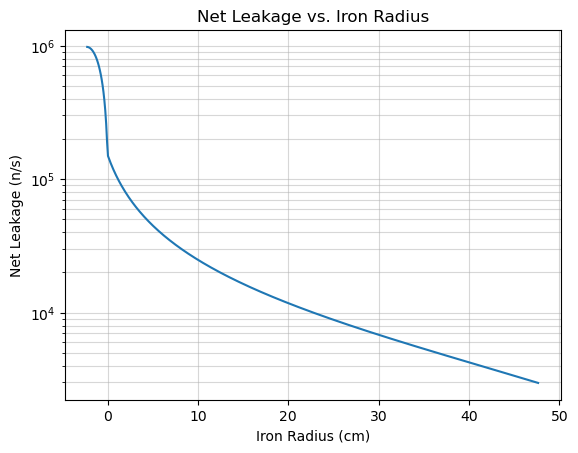

In [12]:
def D(r):
    value = 0.986*(r<2.3) + 10.65*(r>=2.3)
    return value

def Sigma_a(r):
    value = 0.105*(r<2.3) + 5.072e-4*(r>=2.3)
    return value

def nuSigma_f(r):
    value = 0 # we are ignoring fissions
    return value

def Q(r):
    # value = 1e6*(r<=2.3) # can we assume the source term is 1e6 neutrons/cm^3/s?
    value = 1e6*(r<=2.3)
    return value

def slab_analytical_solution(Q, Sigma_a, nuSigma_f, r):
    
    if r <= 5:
        flux = 0.181299*np.exp(-0.34641*r) * (np.exp(0.69282*r) + 1)
    else:
        flux = 34.5868*np.sinh(0.316228*r) - 35.3082*np.cosh(0.316228*r) + 10
    
    return flux

R = 50
I = 500 # I = 1000 gives a runtime of ~19 seconds
BC = [1/4, D(R)/2, 0]

# Sphere
geometry = 2 # sphere
x, phi_sphere = diffusion_solver(R,I,
                                D, Sigma_a, nuSigma_f, Q,
                                BC, geometry, method=0)
# print(x)
# print(phi_sphere)
# out_neutrons = phi_sphere/2*4*np.pi*x**2 # n/cm^2/s * surface area = n/s
out_neutrons = phi_sphere
# print(out_neutrons)
# out_neutrons = phi_sphere
less_mask = out_neutrons <= 1e4
# print(less_mask)
print(f"We need iron shield {x[less_mask][0] - 2.3} cm thick to have less than 1e4 n/s flow out per second")


plt.plot(x-2.3, out_neutrons)
plt.title("Net Leakage vs. Iron Radius")
plt.xlabel("Iron Radius (cm)")
# plt.xscale("log")
plt.ylabel("Net Leakage (n/s)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.yscale("log")
plt.show()

# phi_exact = np.array([slab_analytical_solution(Q, Sigma_a, nuSigma_f, value) for value in x])